In [ ]:
!pip install datasets nltk pandas kaggle -q

In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = 'Omar Al-Eideh'
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_a99524c9788f788b268c67f95131850f'

# !kaggle datasets list

In [ ]:

!kaggle datasets download -d omaraleideh99/tashkeel

Dataset URL: https://www.kaggle.com/datasets/omaraleideh99/tashkeel
License(s): unknown
100% 217M/217M [00:02<00:00, 88.5MB/s]



In [ ]:
!unzip -q tashkeel.zip -d /content/

In [ ]:
#### Added by Omar
# ============================================================
# STEP 1: DATA LOADING & PREPROCESSING
# Arabic Diacritization Project
# ============================================================

import os
import re
import json
import random
from pathlib import Path
from sklearn.model_selection import train_test_split

# ─────────────────────────────────────────
# 1.1 CONFIGURATION
# ─────────────────────────────────────────
DATA_ROOT       = "texts.txt"  # ← change if needed
OUTPUT_DIR      = "./content/data"
MIN_LENGTH      = 20       # minimum characters per sentence
MAX_LENGTH      = 500      # maximum characters per sentence
MIN_DIACRITIC_RATIO = 0.4  # at least 40% of chars must be diacritized
RANDOM_SEED     = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─────────────────────────────────────────
# 1.2 ARABIC UNICODE RANGES
# ─────────────────────────────────────────
DIACRITICS = set([
    '\u064B',  # Tanwin Fath  ً تنوين فتح
    '\u064C',  # Tanwin Damm  ٌ تنوين ضم
    '\u064D',  # Tanwin Kasr  ٍ تنوين كسر
    '\u064E',  # Fatha        َ فتحة
    '\u064F',  # Damma        ُ ضمة
    '\u0650',  # Kasra        ِ كسرة
    '\u0651',  # Shadda       ّ شدة
    '\u0652',  # Sukun        ْ سكون
])

ARABIC_LETTERS = re.compile(r'[\u0621-\u063A\u0641-\u064A]')

# ─────────────────────────────────────────
# 1.3 Normalization function
# ─────────────────────────────────────────

def normalize_arabic(text: str) -> str:
    """
    Normalize Arabic character variants to their base forms.
    Must be applied BEFORE stripping diacritics.
    """

    text = re.sub(r'[أإآٱ]', 'ا', text)   # Normalize Alef variants → bare Alef
#   text = text.replace('ة', 'ه')         #   Normalize Ta Marbuta → Ha
#    text = text.replace('ى', 'ي')         #  Normalize Alef Maqsura → Ya
#    text = text.replace('ؤ', 'و')         #  Normalize Waw with Hamza → Waw
#    text = text.replace('ئ', 'ي')         #  Normalize Ya with Hamza → Ya

    return text

# ─────────────────────────────────────────
# 1.3 CLEANING FUNCTION
# ─────────────────────────────────────────
def clean_line(line):
    """
    Clean a single line of Arabic text:
    - Remove Latin characters
    - Remove digits (Western and Arabic-Indic)
    - Remove brackets, URLs, and special symbols
    - Normalize whitespace
    - Keep Arabic letters, diacritics, and Arabic punctuation
    """
    # Step 1: Normalize Arabic characters first
    line = normalize_arabic(line)

    line = re.sub(r'[a-zA-Z]', '', line)                                  # Remove Latin characters
    line = re.sub(r'[0-9٠-٩]', '', line)                                  # Remove Western and Arabic-Indic digits
    line = re.sub(r'[\[\](){}]', '', line)                                # Remove brackets and parentheses
    line = re.sub(r'http\S+', '', line)                                   # Remove URLs
    line = re.sub(r'[^\u0621-\u0652\u0020]', '', line)  # Keep only: Arabic letters, diacritics, Arabic punctuation, spaces
    line = re.sub(r'\s+', ' ', line).strip()                              # Normalize whitespace

    return line

# ─────────────────────────────────────────
# 1.4 DIACRITIC DENSITY CHECK
# ─────────────────────────────────────────
def has_sufficient_diacritics(line):
    """
    Check that at least MIN_DIACRITIC_RATIO of Arabic
    base characters have an associated diacritic.
    """
    base_chars = ARABIC_LETTERS.findall(line)
    diacritic_chars = [c for c in line if c in DIACRITICS]

    if len(base_chars) == 0:
        return False

    ratio = len(diacritic_chars) / len(base_chars)
    return ratio >= MIN_DIACRITIC_RATIO

# ─────────────────────────────────────────
# 1.5 STRIP DIACRITICS (Create X from Y)
# ─────────────────────────────────────────
def strip_diacritics(text):
    """
    Remove all diacritics from diacritized Arabic text.
    This creates the model input (X) from the ground truth (Y).
    """
    return ''.join(c for c in text if c not in DIACRITICS)

# ─────────────────────────────────────────
# 1.6 LOAD & PROCESS ALL FILES
# ─────────────────────────────────────────
def load_corpus(data_root):
    """
    Walk through all .txt files, clean each line,
    filter, and return list of (input, target) pairs.
    """
    pairs = []
    txt_files = list(Path(data_root).rglob("*.txt"))

    print(f"Found {len(txt_files)} .txt files\n")

    for file_path in txt_files:
        try:
            with open(file_path, 'r', encoding='utf-8-sig') as f:
                lines = f.readlines()
        except Exception as e:
            print(f"  Skipping {file_path.name}: {e}")
            continue

        for line in lines:
            # Step 1: Clean
            cleaned = clean_line(line)

            # Step 2: Length filter
            if not (MIN_LENGTH <= len(cleaned) <= MAX_LENGTH):
                continue

            # Step 3: Diacritic density filter
            if not has_sufficient_diacritics(cleaned):
                continue

            # Step 4: Create (X, Y) pair
            X = strip_diacritics(cleaned)
            Y = cleaned

            pairs.append({"input": X, "target": Y})

    return pairs

# ─────────────────────────────────────────
# 1.7 SPLIT & SAVE
# ─────────────────────────────────────────
def split_and_save(pairs: list, output_dir: str):
    """
    Split into 80/10/10 and save as JSON files.
    """
    # First split: 80% train, 20% temp
    train, temp = train_test_split(
        pairs, test_size=0.2, random_state=RANDOM_SEED
    )

    # Second split: temp → 50% val, 50% test
    val, test = train_test_split(
        temp, test_size=0.5, random_state=RANDOM_SEED
    )

    splits = {"train": train, "val": val, "test": test}

    for name, data in splits.items():
        path = os.path.join(output_dir, f"{name}.json")
        with open(path, 'w', encoding='utf-8') as f:
            json.dump(data, f, ensure_ascii=False, indent=2)
        print(f"Saved {name}: {len(data):,} samples → {path}")

    return train, val, test

# ─────────────────────────────────────────
# 1.8 MAIN EXECUTION
# ─────────────────────────────────────────
print("=" * 50)
print("Loading and preprocessing Tashkeela corpus...")
print("=" * 50)

pairs = load_corpus(DATA_ROOT)
print(f"\nTotal valid pairs after filtering: {len(pairs):,}\n")

sampled_pairs = random.sample(pairs, 50000) # Changed to 50,000 for resources constraints

train, val, test = split_and_save(sampled_pairs, OUTPUT_DIR)

# ─────────────────────────────────────────
# 1.9 SANITY CHECK
# ─────────────────────────────────────────
print("\n--- Sanity Check (3 random samples) ---")
for sample in random.sample(train, 3):
    print(f"  INPUT : {sample['input']}")
    print(f"  TARGET: {sample['target']}")
    print()

Loading and preprocessing Tashkeela corpus...
Found 96 .txt files


Total valid pairs after filtering: 1,094,624

Saved train: 40,000 samples → ./content/data/train.json
Saved val: 5,000 samples → ./content/data/val.json
Saved test: 5,000 samples → ./content/data/test.json

--- Sanity Check (3 random samples) ---
  INPUT : وعنه لا جائحة في غير النخل
  TARGET: وَعَنْهُ لَا جَائِحَةَ فِي غَيْرِ النَّخْلِ

  INPUT : بضم الصاد السكوت
  TARGET: بِضَمِّ الصَّاد السُّكُوت

  INPUT : خلاف الاصل ا هـ
  TARGET: خِلَافُ الْاَصْلِ ا هـ



Loaded 40,000 training samples

--- Sequence Length Statistics ---
  Min    : 9
  Mean   : 116.6
  Median : 100.0
  95th % : 266.0
  99th % : 291.0
  Max    : 316

--- Vocabulary Analysis ---
  Input  vocab size : 35
  Target vocab size : 43
  Extra target chars: {'ْ', 'ٌ', 'ِ', 'ُ', 'َ', 'ٍ', 'ً', 'ّ'}

--- Diacritic Frequency ---
  Fatha (َ)                :  1,404,508  (44.3%)
  Kasra (ِ)                :    584,940  (18.5%)
  Sukun (ْ)                :    515,187  (16.3%)
  Damma (ُ)                :    371,514  (11.7%)
  Shadda (ّ)               :    204,430  (6.5%)
  Tanwin Kasr (ٍ)          :     35,220  (1.1%)
  Tanwin Fath (ً)          :     26,529  (0.8%)
  Tanwin Damm (ٌ)          :     25,517  (0.8%)
  TOTAL                    :  3,167,845

--- Diacritic Density per Sentence ---
  Mean   : 0.837
  Median : 0.840
  Min    : 0.400
  Max    : 1.375


FileNotFoundError: [Errno 2] No such file or directory: '/content/data/eda_plots.png'

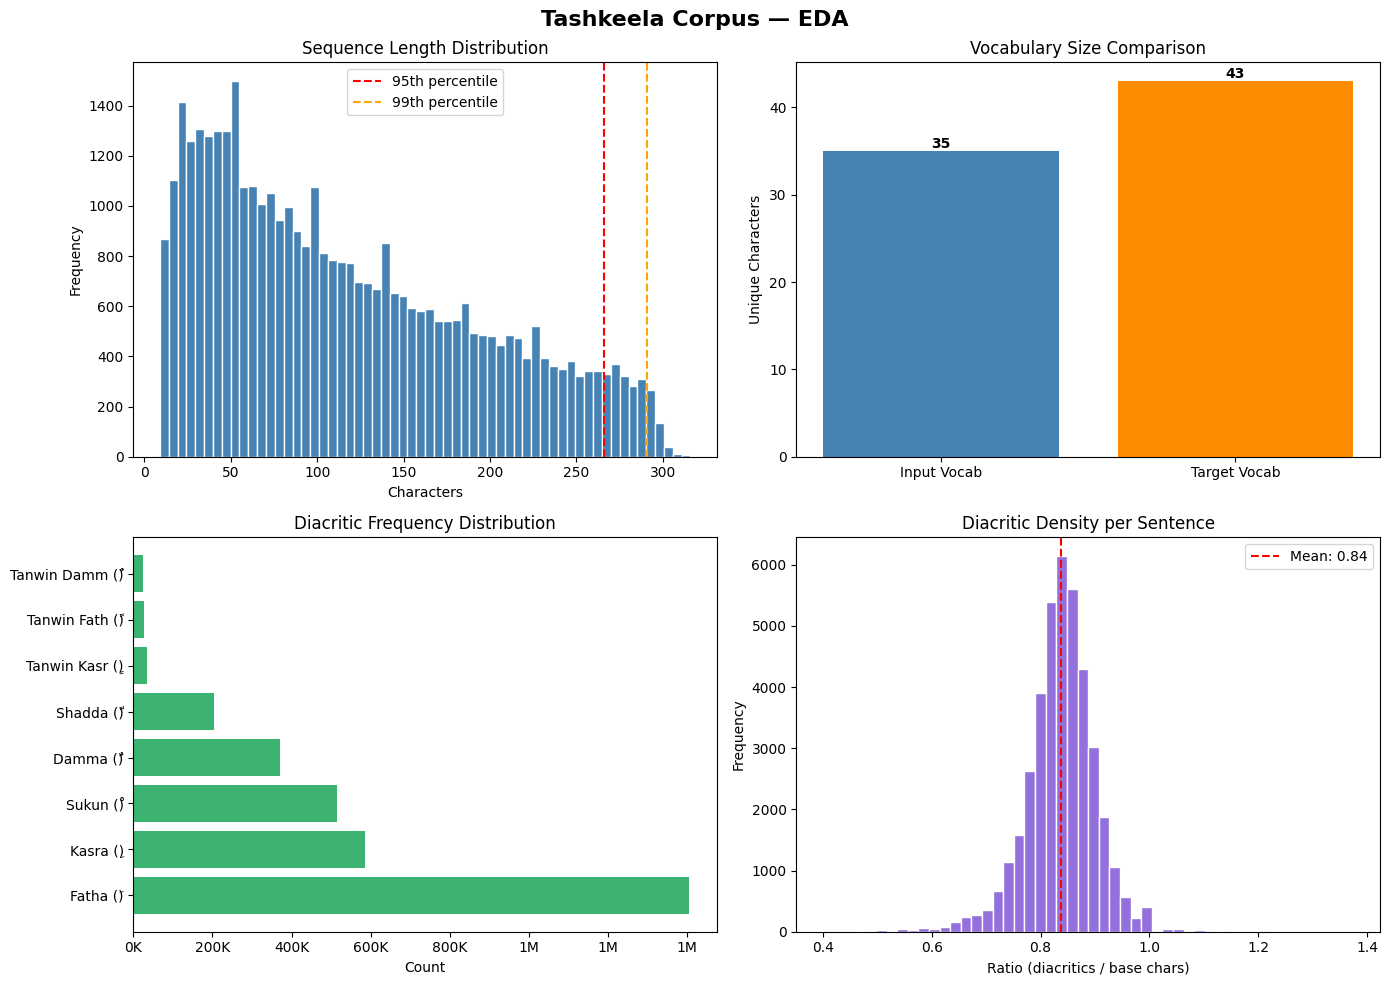

In [ ]:
# ============================================================
# STEP 2: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
from pathlib import Path

# ─────────────────────────────────────────
# 2.1 LOAD TRAINING DATA
# ─────────────────────────────────────────
DATA_DIR = "./content/data"

with open(f"{DATA_DIR}/train.json", 'r', encoding='utf-8') as f:
    train_data = json.load(f)

print(f"Loaded {len(train_data):,} training samples")

inputs  = [s["input"]  for s in train_data]
targets = [s["target"] for s in train_data]

# ─────────────────────────────────────────
# 2.2 SEQUENCE LENGTH DISTRIBUTION
# ─────────────────────────────────────────
input_lengths = [len(s) for s in inputs]

print("\n--- Sequence Length Statistics ---")
print(f"  Min    : {np.min(input_lengths)}")
print(f"  Mean   : {np.mean(input_lengths):.1f}")
print(f"  Median : {np.median(input_lengths):.1f}")
print(f"  95th % : {np.percentile(input_lengths, 95):.1f}")
print(f"  99th % : {np.percentile(input_lengths, 99):.1f}")
print(f"  Max    : {np.max(input_lengths)}")

# ─────────────────────────────────────────
# 2.3 VOCABULARY ANALYSIS
# ─────────────────────────────────────────
input_vocab  = sorted(set(''.join(inputs)))
target_vocab = sorted(set(''.join(targets)))

print("\n--- Vocabulary Analysis ---")
print(f"  Input  vocab size : {len(input_vocab)}")
print(f"  Target vocab size : {len(target_vocab)}")
print(f"  Extra target chars: {set(target_vocab) - set(input_vocab)}")

# ─────────────────────────────────────────
# 2.4 DIACRITIC FREQUENCY DISTRIBUTION
# ─────────────────────────────────────────
DIACRITICS = {
    '\u064B': 'Tanwin Fath (ً)',
    '\u064C': 'Tanwin Damm (ٌ)',
    '\u064D': 'Tanwin Kasr (ٍ)',
    '\u064E': 'Fatha (َ)',
    '\u064F': 'Damma (ُ)',
    '\u0650': 'Kasra (ِ)',
    '\u0651': 'Shadda (ّ)',
    '\u0652': 'Sukun (ْ)',
}

all_target_text = ''.join(targets)
diacritic_counts = {
    name: all_target_text.count(char)
    for char, name in DIACRITICS.items()
}
total_diacritics = sum(diacritic_counts.values())

print("\n--- Diacritic Frequency ---")
for name, count in sorted(diacritic_counts.items(),
                           key=lambda x: x[1], reverse=True):
    print(f"  {name:25s}: {count:>10,}  ({100*count/total_diacritics:.1f}%)")
print(f"  {'TOTAL':25s}: {total_diacritics:>10,}")

# ─────────────────────────────────────────
# 2.5 DIACRITIC DENSITY PER SENTENCE
# ─────────────────────────────────────────
import re
ARABIC_LETTERS = re.compile(r'[\u0621-\u063A\u0641-\u064A]')
DIAC_SET = set(DIACRITICS.keys())

def diacritic_density(sentence):
    base = len(ARABIC_LETTERS.findall(sentence))
    diacs = sum(1 for c in sentence if c in DIAC_SET)
    return diacs / base if base > 0 else 0

densities = [diacritic_density(t) for t in targets]

print("\n--- Diacritic Density per Sentence ---")
print(f"  Mean   : {np.mean(densities):.3f}")
print(f"  Median : {np.median(densities):.3f}")
print(f"  Min    : {np.min(densities):.3f}")
print(f"  Max    : {np.max(densities):.3f}")

# ─────────────────────────────────────────
# 2.6 VISUALIZATIONS
# ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Tashkeela Corpus — EDA", fontsize=16, fontweight='bold')

# Plot 1: Sequence Length Distribution
ax1 = axes[0, 0]
ax1.hist(input_lengths, bins=60, color='steelblue', edgecolor='white')
ax1.axvline(np.percentile(input_lengths, 95),
            color='red', linestyle='--', label='95th percentile')
ax1.axvline(np.percentile(input_lengths, 99),
            color='orange', linestyle='--', label='99th percentile')
ax1.set_title("Sequence Length Distribution")
ax1.set_xlabel("Characters")
ax1.set_ylabel("Frequency")
ax1.legend()

# Plot 2: Vocab Size Comparison
ax2 = axes[0, 1]
ax2.bar(['Input Vocab', 'Target Vocab'],
        [len(input_vocab), len(target_vocab)],
        color=['steelblue', 'darkorange'])
ax2.set_title("Vocabulary Size Comparison")
ax2.set_ylabel("Unique Characters")
for i, v in enumerate([len(input_vocab), len(target_vocab)]):
    ax2.text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# Plot 3: Diacritic Frequency
ax3 = axes[1, 0]
names  = list(diacritic_counts.keys())
counts = list(diacritic_counts.values())
sorted_pairs = sorted(zip(counts, names), reverse=True)
counts_s, names_s = zip(*sorted_pairs)
bars = ax3.barh(names_s, counts_s, color='mediumseagreen')
ax3.set_title("Diacritic Frequency Distribution")
ax3.set_xlabel("Count")
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x/1e6)}M' if x >= 1e6 else f'{int(x/1e3)}K'))

# Plot 4: Diacritic Density Distribution
ax4 = axes[1, 1]
ax4.hist(densities, bins=50, color='mediumpurple', edgecolor='white')
ax4.axvline(np.mean(densities),
            color='red', linestyle='--', label=f'Mean: {np.mean(densities):.2f}')
ax4.set_title("Diacritic Density per Sentence")
ax4.set_xlabel("Ratio (diacritics / base chars)")
ax4.set_ylabel("Frequency")
ax4.legend()

plt.tight_layout()
plt.savefig("/content/data/eda_plots.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved to /content/data/eda_plots.png")

# ─────────────────────────────────────────
# 2.7 KEY DECISIONS SUMMARY
# ─────────────────────────────────────────
recommended_max_len = int(np.percentile(input_lengths, 95))

print("\n" + "="*50)
print("KEY DECISIONS FOR MODEL DESIGN")
print("="*50)
print(f"  Recommended MAX_SEQ_LEN : {recommended_max_len} chars (95th percentile)")
print(f"  Input  vocab size       : {len(input_vocab)}")
print(f"  Target vocab size       : {len(target_vocab)} (+3 special tokens = {len(target_vocab)+3})")
print(f"  Class imbalance?        : {'Yes — consider weighted loss' if max(diacritic_counts.values())/min(diacritic_counts.values()) > 5 else 'Mild — standard loss is fine'}")
print(f"  Avg diacritic density   : {np.mean(densities):.1%}")

In [ ]:
input_vocab

In [ ]:
# ============================================================
# STEP 3: TOKENIZATION & VOCABULARY BUILDING
# ============================================================

import json
import numpy as np
from pathlib import Path
from collections import Counter

# ─────────────────────────────────────────
# 3.1 CONFIGURATION
# ─────────────────────────────────────────
DATA_DIR    = "./content/data"
MAX_SEQ_LEN = 250
PAD_TOKEN   = "<PAD>"   # index 0
SOS_TOKEN   = "<SOS>"   # index 1
EOS_TOKEN   = "<EOS>"   # index 2

# ─────────────────────────────────────────
# 3.2 VOCABULARY CLASS
# ─────────────────────────────────────────
class Vocabulary:
    def __init__(self, name: str, is_target: bool = False):
        """
        name      : 'input' or 'target'
        is_target : if True, adds SOS and EOS tokens
                    and wraps encoded sequences with them
        """
        self.name      = name
        self.is_target = is_target

        # Special tokens always at fixed indices
        self.char2idx = {PAD_TOKEN: 0}
        self.idx2char = {0: PAD_TOKEN}
        self._next_idx = 1

        if is_target:
            self._add_token(SOS_TOKEN)  # index 1
            self._add_token(EOS_TOKEN)  # index 2

    def _add_token(self, token: str):
        if token not in self.char2idx:
            self.char2idx[token] = self._next_idx
            self.idx2char[self._next_idx] = token
            self._next_idx += 1

    def build(self, texts: list):
        """
        Scan all characters in texts and assign indices.
        Sorts characters for deterministic ordering.
        """
        all_chars = sorted(set(''.join(texts)))
        for char in all_chars:
            self._add_token(char)
        print(f"  [{self.name}] vocab size: {len(self.char2idx)}")

    def encode(self, sentence: str, max_len: int = MAX_SEQ_LEN) -> list:
        """
        Convert sentence to padded integer sequence.
        Target sequences are wrapped with SOS and EOS.
        """
        indices = [self.char2idx.get(c, 0) for c in sentence]

        if self.is_target:
            indices = [self.char2idx[SOS_TOKEN]] + \
                       indices + \
                      [self.char2idx[EOS_TOKEN]]

        # Truncate if needed (rare, given our MAX_SEQ_LEN=300)
        indices = indices[:max_len]

        # Post-padding
        pad_len = max_len - len(indices)
        indices = indices + [self.char2idx[PAD_TOKEN]] * pad_len

        return indices

    def decode(self, indices: list, remove_special: bool = True) -> str:
        """
        Convert integer sequence back to string.
        Stops at EOS if present.
        """
        chars = []
        for idx in indices:
            token = self.idx2char.get(idx, '')

            # Stop at EOS
            if token == EOS_TOKEN:
                break

            # Optionally skip special tokens
            if remove_special and token in {PAD_TOKEN, SOS_TOKEN, EOS_TOKEN}:
                continue

            chars.append(token)

        return ''.join(chars)

    def __len__(self):
        return len(self.char2idx)

    def save(self, path: str):
        data = {
            "name"      : self.name,
            "is_target" : self.is_target,
            "char2idx"  : self.char2idx,
        }
        with open(path, 'w', encoding='utf-8') as f:
            json.dump(data, f, ensure_ascii=False, indent=2)
        print(f"  [{self.name}] vocab saved → {path}")

    @classmethod
    def load(cls, path: str):
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        vocab = cls(data["name"], data["is_target"])
        vocab.char2idx  = data["char2idx"]
        vocab.idx2char  = {int(k): v for k, v
                           in {v: k for k, v
                           in data["char2idx"].items()}.items()}
        vocab._next_idx = max(vocab.char2idx.values()) + 1
        return vocab

# ─────────────────────────────────────────
# 3.3 BUILD VOCABULARIES
# ─────────────────────────────────────────
print("=" * 50)
print("Building vocabularies...")
print("=" * 50)

with open(f"{DATA_DIR}/train.json", 'r', encoding='utf-8') as f:
    train_data = json.load(f)

inputs  = [s["input"]  for s in train_data]
targets = [s["target"] for s in train_data]

input_vocab  = Vocabulary("input",  is_target=False)
target_vocab = Vocabulary("target", is_target=True)

input_vocab.build(inputs)
target_vocab.build(targets)

# ─────────────────────────────────────────
# 3.4 CLASS WEIGHTS FOR LOSS FUNCTION
# ─────────────────────────────────────────
print("\nComputing class weights...")

# Count every target character across all training sentences
all_target_chars = Counter(''.join(targets))

# Build frequency array aligned to target vocab indices
n_classes    = len(target_vocab)
freq         = np.zeros(n_classes, dtype=np.float64)

for char, idx in target_vocab.char2idx.items():
    if char in all_target_chars:
        freq[idx] = all_target_chars[char]

# Balanced weight formula: total / (n_classes * count)
total        = freq.sum()
weights      = np.zeros(n_classes, dtype=np.float32)
nonzero_mask = freq > 0
weights[nonzero_mask] = total / (n_classes * freq[nonzero_mask])

# PAD token always gets weight 0
weights[target_vocab.char2idx[PAD_TOKEN]] = 0.0

print(f"  Class weights computed for {n_classes} classes")
print(f"  PAD  weight : {weights[0]:.4f}  (always 0)")
print(f"  Max  weight : {weights.max():.4f}")
print(f"  Min  weight : {weights[weights > 0].min():.4f}")

# ─────────────────────────────────────────
# 3.5 Dynamic Padding Per Batch
# ─────────────────────────────────────────
def collate_fn(batch):
    """
    Custom collate: pad each batch to its own max length.
    """
    inputs, targets, masks = zip(*batch)

    # Find max length in THIS batch
    max_len = max(inp.nonzero().max().item() + 1
                  if inp.nonzero().numel() > 0 else 1
                  for inp in inputs)
    max_len = min(max_len, MAX_SEQ_LEN)

    # Trim all sequences to max_len
    inputs  = torch.stack([i[:max_len] for i in inputs])
    targets = torch.stack([t[:max_len] for t in targets])
    masks   = torch.stack([m[:max_len] for m in masks])

    return inputs, targets, masks

# ─────────────────────────────────────────
# 3.6 SAVE EVERYTHING
# ─────────────────────────────────────────
print("\nSaving...")

input_vocab.save(f"{DATA_DIR}/input_vocab.json")
target_vocab.save(f"{DATA_DIR}/target_vocab.json")
np.save(f"{DATA_DIR}/class_weights.npy", weights)
print(f"  class_weights saved → {DATA_DIR}/class_weights.npy")

# ─────────────────────────────────────────
# 3.7 SANITY CHECKS
# ─────────────────────────────────────────
print("\n--- Sanity Checks ---")

sample_input  = inputs[0]
sample_target = targets[0]

encoded_input  = input_vocab.encode(sample_input)
encoded_target = target_vocab.encode(sample_target)

decoded_input  = input_vocab.decode(encoded_input)
decoded_target = target_vocab.decode(encoded_target)

print(f"\n  Original  input : {sample_input[:50]}")
print(f"  Decoded   input : {decoded_input[:50]}")
print(f"  Match           : {sample_input == decoded_input}")

print(f"\n  Original  target: {sample_target[:50]}")
print(f"  Decoded   target: {decoded_target[:50]}")
print(f"  Match           : {sample_target == decoded_target}")

print(f"\n  Encoded input  (first 15 indices): {encoded_input[:15]}")
print(f"  Encoded target (first 15 indices): {encoded_target[:15]}")
print(f"  Target starts with SOS (idx=1)   : {encoded_target[0] == 1}")

# Check PAD positions
input_pad_count  = encoded_input.count(0)
target_pad_count = encoded_target.count(0)
print(f"\n  Input  PAD positions : {MAX_SEQ_LEN - input_pad_count} chars + "
      f"{input_pad_count} pads")
print(f"  Target PAD positions : {MAX_SEQ_LEN - target_pad_count} chars + "
      f"{target_pad_count} pads")

# ─────────────────────────────────────────
# 3.8 SUMMARY
# ─────────────────────────────────────────
print("\n" + "="*50)
print("STEP 3 SUMMARY")
print("="*50)
print(f"  Input  vocab size : {len(input_vocab)}")
print(f"  Target vocab size : {len(target_vocab)}")
print(f"  MAX_SEQ_LEN       : {MAX_SEQ_LEN}")
print(f"  Class weights     : computed & saved")
print(f"  Encode→Decode     : lossless ✓")

Building vocabularies...
  [input] vocab size: 36
  [target] vocab size: 46

Computing class weights...
  Class weights computed for 46 classes
  PAD  weight : 0.0000  (always 0)
  Max  weight : 101.9028
  Min  weight : 0.1212

Saving...
  [input] vocab saved → ./content/data/input_vocab.json
  [target] vocab saved → ./content/data/target_vocab.json
  class_weights saved → ./content/data/class_weights.npy

--- Sanity Checks ---

  Original  input : ومندوبة كاحداث المدارس والربط
  Decoded   input : ومندوبة كاحداث المدارس والربط
  Match           : True

  Original  target: وَمَنْدُوبَةٌ كَاِحْدَاثِ الْمَدَارِسِ وَالرَّبْطِ
  Decoded   target: وَمَنْدُوبَةٌ كَاِحْدَاثِ الْمَدَارِسِ وَالرَّبْطِ
  Match           : True

  Encoded input  (first 15 indices): [33, 30, 31, 13, 33, 6, 7, 1, 28, 5, 11, 13, 5, 9, 1]
  Encoded target (first 15 indices): [1, 35, 41, 32, 41, 33, 45, 15, 42, 35, 8, 41, 9, 39, 3]
  Target starts with SOS (idx=1)   : True

  Input  PAD positions : 29 chars + 221 pads


In [ ]:
# ============================================================
# STEP 4: DATASET & DATALOADER
# ============================================================

import json
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

# ─────────────────────────────────────────
# 4.1 CONFIGURATION
# ─────────────────────────────────────────
DATA_DIR    = "./content/data"
MAX_SEQ_LEN = 100
BATCH_SIZE  = 64
NUM_WORKERS = 0   # parallel loading workers

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ─────────────────────────────────────────
# 4.2 LOAD VOCABULARIES
# ─────────────────────────────────────────
input_vocab  = Vocabulary.load(f"{DATA_DIR}/input_vocab.json")
target_vocab = Vocabulary.load(f"{DATA_DIR}/target_vocab.json")

PAD_IDX = target_vocab.char2idx[PAD_TOKEN]  # 0
SOS_IDX = target_vocab.char2idx[SOS_TOKEN]  # 1
EOS_IDX = target_vocab.char2idx[EOS_TOKEN]  # 2

print(f"Vocabularies loaded")
print(f"  Input  vocab : {len(input_vocab)}")
print(f"  Target vocab : {len(target_vocab)}")

# ─────────────────────────────────────────
# 4.3 DATASET CLASS
# ─────────────────────────────────────────
class TashkeelDataset(Dataset):
    def __init__(self,
                 data_path   : str,
                 input_vocab : Vocabulary,
                 target_vocab: Vocabulary,
                 max_len     : int = MAX_SEQ_LEN):
        """
        Args:
            data_path   : path to train/val/test JSON file
            input_vocab : Vocabulary for encoder side
            target_vocab: Vocabulary for decoder side
            max_len     : maximum sequence length
        """
        self.input_vocab  = input_vocab
        self.target_vocab = target_vocab
        self.max_len      = max_len

        with open(data_path, 'r', encoding='utf-8') as f:
            self.data = json.load(f)

        print(f"  Loaded {len(self.data):,} samples from {data_path}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        """
        Returns one (input, target) pair as tensors.

        input_tensor : (MAX_SEQ_LEN,)  integer indices, post-padded
        target_tensor: (MAX_SEQ_LEN,)  integer indices, SOS...EOS, post-padded
        input_mask   : (MAX_SEQ_LEN,)  1=real token, 0=PAD
        """
        sample = self.data[idx]

        # Encode both sides
        input_ids  = self.input_vocab.encode(
            sample["input"],  max_len=self.max_len
        )
        target_ids = self.target_vocab.encode(
            sample["target"], max_len=self.max_len
        )

        input_tensor  = torch.tensor(input_ids,  dtype=torch.long)
        target_tensor = torch.tensor(target_ids, dtype=torch.long)

        # Padding mask: True where real token, False where PAD
        input_mask = (input_tensor != PAD_IDX)

        return input_tensor, target_tensor, input_mask

# ─────────────────────────────────────────
# 4.4 CREATE DATASETS
# ─────────────────────────────────────────
print("\nCreating datasets...")

train_dataset = TashkeelDataset(
    f"{DATA_DIR}/train.json", input_vocab, target_vocab
)
val_dataset = TashkeelDataset(
    f"{DATA_DIR}/val.json",   input_vocab, target_vocab
)
test_dataset = TashkeelDataset(
    f"{DATA_DIR}/test.json",  input_vocab, target_vocab
)

# ─────────────────────────────────────────
# 4.5 CREATE DATALOADERS
# ─────────────────────────────────────────
print("\nCreating dataloaders...")

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,        # shuffle every epoch
    num_workers = NUM_WORKERS,
    pin_memory  = True,        # faster CPU→GPU transfer
    collate_fn  = collate_fn   # dynamic padding
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,      # no shuffling for val/test
    num_workers = NUM_WORKERS,
    pin_memory  = True,
    collate_fn  = collate_fn   # dynamic padding
)

test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = True,
    collate_fn  = collate_fn   # dynamic padding
)

print(f"  Train batches : {len(train_loader):,}")
print(f"  Val   batches : {len(val_loader):,}")
print(f"  Test  batches : {len(test_loader):,}")

# ─────────────────────────────────────────
# 4.6 SANITY CHECKS
# ─────────────────────────────────────────
print("\n--- Sanity Checks ---")

# Grab one batch
input_batch, target_batch, mask_batch = next(iter(train_loader))

print(f"\n  input_batch  shape : {input_batch.shape}")
print(f"  target_batch shape : {target_batch.shape}")
print(f"  mask_batch   shape : {mask_batch.shape}")

# Verify dtypes
print(f"\n  input_batch  dtype : {input_batch.dtype}   (expect torch.int64)")
print(f"  target_batch dtype : {target_batch.dtype}   (expect torch.int64)")
print(f"  mask_batch   dtype : {mask_batch.dtype}  (expect torch.bool)")

# Verify first sample in batch
print(f"\n  First sample:")
print(f"    input  (first 10 idx) : {input_batch[0, :10].tolist()}")
print(f"    target (first 10 idx) : {target_batch[0, :10].tolist()}")
print(f"    mask   (first 10)     : {mask_batch[0, :10].tolist()}")

# Verify SOS is first target token
print(f"\n  Target starts with SOS (idx=1): "
      f"{(target_batch[:, 0] == SOS_IDX).all().item()}")

# Verify PAD mask correctness
real_tokens = mask_batch[0].sum().item()
print(f"\n  Sample 0: {real_tokens} real tokens, "
      f"{MAX_SEQ_LEN - real_tokens} padded positions")

# Teacher forcing split
decoder_input  = target_batch[:, :-1]  # drop last token
decoder_output = target_batch[:, 1:]   # drop SOS

print(f"\n  Teacher forcing:")
print(f"    decoder_input  shape : {decoder_input.shape}")
print(f"    decoder_output shape : {decoder_output.shape}")
print(f"    decoder_input  starts with SOS : "
      f"{(decoder_input[:, 0] == SOS_IDX).all().item()}")
print(f"    decoder_output starts with SOS : "
      f"{(decoder_output[:, 0] == SOS_IDX).all().item()}")

# ─────────────────────────────────────────
# 4.7 SUMMARY
# ─────────────────────────────────────────
print("\n" + "="*50)
print("STEP 4 SUMMARY")
print("="*50)
print(f"  Train dataset : {len(train_dataset):,} samples")
print(f"  Val   dataset : {len(val_dataset):,}  samples")
print(f"  Test  dataset : {len(test_dataset):,}  samples")
print(f"  Batch size    : {BATCH_SIZE}")
print(f"  Train batches : {len(train_loader):,}")
print(f"  Device        : {DEVICE}")
print(f"  Teacher forcing verified : ✓")

Device: cuda
Vocabularies loaded
  Input  vocab : 36
  Target vocab : 46

Creating datasets...
  Loaded 40,000 samples from ./content/data/train.json
  Loaded 5,000 samples from ./content/data/val.json
  Loaded 5,000 samples from ./content/data/test.json

Creating dataloaders...
  Train batches : 625
  Val   batches : 79
  Test  batches : 79

--- Sanity Checks ---

  input_batch  shape : torch.Size([64, 100])
  target_batch shape : torch.Size([64, 100])
  mask_batch   shape : torch.Size([64, 100])

  input_batch  dtype : torch.int64   (expect torch.int64)
  target_batch dtype : torch.int64   (expect torch.int64)
  mask_batch   dtype : torch.bool  (expect torch.bool)

  First sample:
    input  (first 10 idx) : [33, 5, 31, 1, 28, 26, 29, 1, 5, 29]
    target (first 10 idx) : [1, 35, 41, 7, 43, 33, 45, 3, 30, 41]
    mask   (first 10)     : [True, True, True, True, True, True, True, True, True, True]

  Target starts with SOS (idx=1): True

  Sample 0: 100 real tokens, 0 padded positions

In [ ]:
# ============================================================
# STEP 5: MODEL ARCHITECTURE
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

# ─────────────────────────────────────────
# 5.1 CONFIGURATION
# ─────────────────────────────────────────
EMBED_DIM  = 256
HIDDEN_DIM = 512
NUM_LAYERS = 2
DROPOUT    = 0.3

INPUT_VOCAB_SIZE  = len(input_vocab)   # 32
OUTPUT_VOCAB_SIZE = len(target_vocab)  # 42

# ─────────────────────────────────────────
# 5.2 ENCODER
# ─────────────────────────────────────────
class Encoder(nn.Module):
    def __init__(self,
                 input_vocab_size: int,
                 embed_dim       : int,
                 hidden_dim      : int,
                 num_layers      : int,
                 dropout         : float):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Character embedding
        self.embedding = nn.Embedding(
            input_vocab_size,
            embed_dim,
            padding_idx=0   # PAD index → zero vector, no gradient
        )

        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size   = embed_dim,
            hidden_size  = hidden_dim,
            num_layers   = num_layers,
            dropout      = dropout if num_layers > 1 else 0,
            bidirectional= True,
            batch_first  = True    # (batch, seq, features)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_mask):
        """
        Args:
            src      : (batch, seq_len)        integer indices
            src_mask : (batch, seq_len)         boolean mask

        Returns:
            encoder_outputs: (batch, seq_len, hidden_dim*2)
            hidden         : (num_layers, batch, hidden_dim)
            cell           : (num_layers, batch, hidden_dim)
        """
        # (batch, seq_len) → (batch, seq_len, embed_dim)
        embedded = self.dropout(self.embedding(src))

        # Pack padded sequence for efficiency
        lengths = src_mask.sum(dim=1).cpu()
        packed  = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths,
            batch_first=True,
            enforce_sorted=False
        )

        # Run BiLSTM
        # encoder_outputs: (batch, seq_len, hidden_dim*2)
        # hidden/cell    : (num_layers*2, batch, hidden_dim)
        packed_outputs, (hidden, cell) = self.lstm(packed)
        encoder_outputs, _ = nn.utils.rnn.pad_packed_sequence(
            packed_outputs,
            batch_first  =True,
            total_length =src.size(1)
        )

        # Merge bidirectional hidden states
        # (num_layers*2, batch, hidden_dim)
        # → (num_layers, batch, hidden_dim*2)
        # → (num_layers, batch, hidden_dim)  via projection
        hidden = self._merge_bidirectional(hidden)
        cell   = self._merge_bidirectional(cell)

        return encoder_outputs, hidden, cell

    def _merge_bidirectional(self, state):
        """
        Concatenate forward and backward states,
        then project back to hidden_dim.
        Input : (num_layers*2, batch, hidden_dim)
        Output: (num_layers,   batch, hidden_dim)
        """
        # Reshape: separate layers and directions
        # (num_layers*2, batch, hidden_dim)
        # → (num_layers, 2, batch, hidden_dim)
        num_layers = state.size(0) // 2
        batch_size = state.size(1)

        state = state.view(num_layers, 2, batch_size, self.hidden_dim)

        # Concatenate forward (0) and backward (1)
        # → (num_layers, batch, hidden_dim*2)
        state = torch.cat([state[:, 0, :, :],
                           state[:, 1, :, :]], dim=2)

        return state

# ─────────────────────────────────────────
# 5.3 BAHDANAU ATTENTION
# ─────────────────────────────────────────
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim: int):
        super().__init__()

        # Projects encoder outputs (hidden_dim*2) → hidden_dim
        self.W1 = nn.Linear(hidden_dim * 2, hidden_dim, bias=False)

        # Projects decoder hidden (hidden_dim) → hidden_dim
        self.W2 = nn.Linear(hidden_dim, hidden_dim, bias=False)

        # Scores the combined representation → scalar
        self.V  = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, encoder_outputs, decoder_hidden, src_mask):
        """
        Args:
            encoder_outputs: (batch, src_len, hidden_dim*2)
            decoder_hidden : (batch, hidden_dim)
            src_mask       : (batch, src_len) boolean

        Returns:
            context        : (batch, hidden_dim*2)
            attn_weights   : (batch, src_len)
        """
        # Project encoder outputs
        # (batch, src_len, hidden_dim)
        encoder_energy = self.W1(encoder_outputs)

        # Project decoder hidden, expand for broadcasting
        # (batch, hidden_dim) → (batch, 1, hidden_dim)
        decoder_energy = self.W2(decoder_hidden).unsqueeze(1)

        # Compute attention scores
        # (batch, src_len, hidden_dim) → (batch, src_len, 1)
        energy = self.V(torch.tanh(encoder_energy + decoder_energy))

        # (batch, src_len, 1) → (batch, src_len)
        energy = energy.squeeze(2)

        # Mask PAD positions (set to -inf before softmax)
        energy = energy.masked_fill(~src_mask, float('-inf'))

        # Normalize → attention weights
        attn_weights = F.softmax(energy, dim=1)

        # Weighted sum of encoder outputs
        # (batch, 1, src_len) x (batch, src_len, hidden_dim*2)
        # → (batch, 1, hidden_dim*2) → (batch, hidden_dim*2)
        context = torch.bmm(
            attn_weights.unsqueeze(1),
            encoder_outputs
        ).squeeze(1)

        return context, attn_weights

# ─────────────────────────────────────────
# 5.4 DECODER
# ─────────────────────────────────────────
class Decoder(nn.Module):
    def __init__(self,
                 output_vocab_size: int,
                 embed_dim        : int,
                 hidden_dim       : int,
                 num_layers       : int,
                 dropout          : float):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Character embedding for decoder input
        self.embedding = nn.Embedding(
            output_vocab_size,
            embed_dim,
            padding_idx=0
        )

        # Attention module
        self.attention = BahdanauAttention(hidden_dim)

        # Project BiLSTM hidden → decoder hidden (once, at init)
        self.hidden_proj = nn.Linear(hidden_dim * 2, hidden_dim)
        self.cell_proj   = nn.Linear(hidden_dim * 2, hidden_dim)

        # LSTM input = embedding + context vector
        self.lstm = nn.LSTM(
            input_size  = embed_dim + hidden_dim * 2,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            dropout     = dropout if num_layers > 1 else 0,
            batch_first = True
        )

        # Output projection → vocab logits
        self.fc_out = nn.Linear(
            hidden_dim + hidden_dim * 2,
            output_vocab_size
        )

        self.dropout = nn.Dropout(dropout)

    def project_encoder_state(self, hidden, cell):
        """
        Project encoder BiLSTM states to decoder LSTM size.

        Input : (num_layers, batch, hidden_dim*2)
        Output: (num_layers, batch, hidden_dim)
        """
        # Process all layers at once
        # Reshape to (num_layers*batch, hidden_dim*2)
        num_layers, batch, _ = hidden.size()

        hidden = self.hidden_proj(
            hidden.reshape(-1, self.hidden_dim * 2)
        ).reshape(num_layers, batch, self.hidden_dim)

        cell = self.cell_proj(
            cell.reshape(-1, self.hidden_dim * 2)
        ).reshape(num_layers, batch, self.hidden_dim)

        return hidden, cell

    def forward_step(self,
                     tgt_token      : torch.Tensor,
                     hidden         : torch.Tensor,
                     cell           : torch.Tensor,
                     encoder_outputs: torch.Tensor,
                     src_mask       : torch.Tensor):
        """
        One decoder step — predicts one output token.

        Args:
            tgt_token      : (batch,)              current input token
            hidden         : (num_layers, batch, hidden_dim)
            cell           : (num_layers, batch, hidden_dim)
            encoder_outputs: (batch, src_len, hidden_dim*2)
            src_mask       : (batch, src_len)

        Returns:
            logits         : (batch, output_vocab_size)
            hidden         : (num_layers, batch, hidden_dim)
            cell           : (num_layers, batch, hidden_dim)
            attn_weights   : (batch, src_len)
        """
        # Embed current token
        # (batch,) → (batch, 1, embed_dim)
        embedded = self.dropout(
            self.embedding(tgt_token.unsqueeze(1))
        )

        # Attention: use top layer hidden state
        # hidden[-1]: (batch, hidden_dim)
        context, attn_weights = self.attention(
            encoder_outputs,
            hidden[-1],
            src_mask
        )

        # Concatenate embedding + context
        # (batch, 1, embed_dim + hidden_dim*2)
        lstm_input = torch.cat(
            [embedded, context.unsqueeze(1)], dim=2
        )

        # LSTM step
        lstm_out, (hidden, cell) = self.lstm(
            lstm_input, (hidden, cell)
        )

        # lstm_out: (batch, 1, hidden_dim) → (batch, hidden_dim)
        lstm_out = lstm_out.squeeze(1)

        # Predict: concatenate lstm_out + context → logits
        # (batch, hidden_dim + hidden_dim*2)
        output = self.fc_out(
            torch.cat([lstm_out, context], dim=1)
        )

        return output, hidden, cell, attn_weights

# ─────────────────────────────────────────
# 5.5 SEQ2SEQ MODEL
# ─────────────────────────────────────────
class Seq2Seq(nn.Module):
    def __init__(self,
                 encoder        : Encoder,
                 decoder        : Decoder,
                 device         : torch.device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self,
                src           : torch.Tensor,
                tgt           : torch.Tensor,
                src_mask      : torch.Tensor,
                teacher_forcing: float = 0.5):
        """
        Full forward pass with teacher forcing.

        Args:
            src            : (batch, src_len)   encoder input
            tgt            : (batch, tgt_len)   decoder input (with SOS)
            src_mask       : (batch, src_len)   padding mask
            teacher_forcing: probability of using ground truth
                             as next decoder input

        Returns:
            outputs        : (batch, tgt_len-1, vocab_size)
                             predictions for each position
        """
        batch_size = src.size(0)
        tgt_len    = tgt.size(1)

        # Encode
        encoder_outputs, hidden, cell = self.encoder(src, src_mask)

        # Project encoder state to decoder size
        hidden, cell = self.decoder.project_encoder_state(
            hidden, cell
        )

        # Storage for all predictions
        # (batch, tgt_len-1, vocab_size)
        outputs = torch.zeros(
            batch_size,
            tgt_len - 1,
            OUTPUT_VOCAB_SIZE
        ).to(self.device)

        # First decoder input is always SOS
        dec_input = tgt[:, 0]   # (batch,) — SOS tokens

        # Decode step by step
        for t in range(tgt_len - 1):
            logits, hidden, cell, _ = self.decoder.forward_step(
                dec_input,
                hidden,
                cell,
                encoder_outputs,
                src_mask
            )

            outputs[:, t, :] = logits

            # Teacher forcing decision
            use_teacher = torch.rand(1).item() < teacher_forcing
            if use_teacher:
                dec_input = tgt[:, t + 1]        # ground truth
            else:
                dec_input = logits.argmax(dim=1)  # model prediction

        return outputs

    def predict(self, src, src_mask, max_len=MAX_SEQ_LEN):
        """
        Greedy inference — no teacher forcing.
        Used at evaluation and test time.
        """
        self.eval()
        with torch.no_grad():
            encoder_outputs, hidden, cell = self.encoder(
                src, src_mask
            )
            hidden, cell = self.decoder.project_encoder_state(
                hidden, cell
            )

            # Start with SOS
            dec_input = torch.full(
                (src.size(0),), SOS_IDX,
                dtype=torch.long, device=self.device
            )

            predictions = []
            for _ in range(max_len - 1):
                logits, hidden, cell, _ = self.decoder.forward_step(
                    dec_input, hidden, cell,
                    encoder_outputs, src_mask
                )
                pred = logits.argmax(dim=1)
                predictions.append(pred)
                dec_input = pred

        # (batch, max_len-1)
        return torch.stack(predictions, dim=1)

# ─────────────────────────────────────────
# 5.6 INSTANTIATE & VERIFY
# ─────────────────────────────────────────
print("=" * 50)
print("Building model...")
print("=" * 50)

encoder = Encoder(
    input_vocab_size = INPUT_VOCAB_SIZE,
    embed_dim        = EMBED_DIM,
    hidden_dim       = HIDDEN_DIM,
    num_layers       = NUM_LAYERS,
    dropout          = DROPOUT
)

decoder = Decoder(
    output_vocab_size = OUTPUT_VOCAB_SIZE,
    embed_dim         = EMBED_DIM,
    hidden_dim        = HIDDEN_DIM,
    num_layers        = NUM_LAYERS,
    dropout           = DROPOUT
)

model = Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)

# ─────────────────────────────────────────
# 5.7 PARAMETER COUNT
# ─────────────────────────────────────────
def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters()
                    if p.requires_grad)
    return total, trainable

total, trainable = count_parameters(model)
print(f"\n  Total parameters     : {total:,}")
print(f"  Trainable parameters : {trainable:,}")

# ─────────────────────────────────────────
# 5.8 FORWARD PASS SANITY CHECK
# ─────────────────────────────────────────
print("\n--- Forward Pass Sanity Check ---")

src_batch, tgt_batch, mask_batch = next(iter(train_loader))
src_batch  = src_batch.to(DEVICE)
tgt_batch  = tgt_batch.to(DEVICE)
mask_batch = mask_batch.to(DEVICE)

with torch.no_grad():
    output = model(
        src_batch,
        tgt_batch,       # ← pass FULL target, not pre-split
        mask_batch,
        teacher_forcing=1.0
    )

# Ground truth for loss comparison
ground_truth = tgt_batch[:, 1:]   # drop SOS → (32, 299)

print(f"\n  Input        shape : {src_batch.shape}")
print(f"  Full target  shape : {tgt_batch.shape}")
print(f"  Output       shape : {output.shape}")
print(f"  Ground truth shape : {ground_truth.shape}")
print(f"  Expected           : (32, 299, 42)")
print(f"  Match              : {tuple(output.shape) == (32, 299, 42)}")
print(f"\n  Output min   : {output.min().item():.4f}")
print(f"  Output max   : {output.max().item():.4f}")
print(f"  Contains NaN : {torch.isnan(output).any().item()}")
print(f"  Contains Inf : {torch.isinf(output).any().item()}")

# ─────────────────────────────────────────
# 5.9 SUMMARY
# ─────────────────────────────────────────
print("\n" + "="*50)
print("STEP 5 SUMMARY")
print("="*50)
print(f"  Encoder  : BiLSTM  | layers={NUM_LAYERS} | "
      f"hidden={HIDDEN_DIM} | embed={EMBED_DIM}")
print(f"  Attention: Bahdanau")
print(f"  Decoder  : LSTM    | layers={NUM_LAYERS} | "
      f"hidden={HIDDEN_DIM} | embed={EMBED_DIM}")
print(f"  Dropout  : {DROPOUT}")
print(f"  Params   : {trainable:,}")
print(f"  Device   : {DEVICE}")

Building model...

  Total parameters     : 17,157,166
  Trainable parameters : 17,157,166

--- Forward Pass Sanity Check ---

  Input        shape : torch.Size([64, 100])
  Full target  shape : torch.Size([64, 100])
  Output       shape : torch.Size([64, 99, 46])
  Ground truth shape : torch.Size([64, 99])
  Expected           : (32, 299, 42)
  Match              : False

  Output min   : -0.0887
  Output max   : 0.0812
  Contains NaN : False
  Contains Inf : False

STEP 5 SUMMARY
  Encoder  : BiLSTM  | layers=2 | hidden=512 | embed=256
  Attention: Bahdanau
  Decoder  : LSTM    | layers=2 | hidden=512 | embed=256
  Dropout  : 0.3
  Params   : 17,157,166
  Device   : cuda


Starting Training

Epoch 1/30 | Teacher Forcing: 1.0 | LR: 0.001000
------------------------------------------------------------
    Batch    500/625 | Loss: 0.7934 | Acc: 0.6846 | Last 500 batches: 3266.5s | Total: 3266.5s

  Epoch  1 Summary:
    Train Loss : 0.6577 | Train Acc : 0.7265
    Val   Loss : 5.6404   | Val   Acc : 0.4068
    Time       : 4123.4s
    ✓ Best model saved (val_loss=5.6404)

Epoch 2/30 | Teacher Forcing: 1.0 | LR: 0.001000
------------------------------------------------------------
    Batch    500/625 | Loss: 0.0910 | Acc: 0.9180 | Last 500 batches: 3412.2s | Total: 3412.2s

  Epoch  2 Summary:
    Train Loss : 0.0889 | Train Acc : 0.9201
    Val   Loss : 4.0910   | Val   Acc : 0.5876
    Time       : 4304.4s
    ✓ Best model saved (val_loss=4.0910)

Epoch 3/30 | Teacher Forcing: 1.0 | LR: 0.001000
------------------------------------------------------------
    Batch    500/625 | Loss: 0.0718 | Acc: 0.9373 | Last 500 batches: 3402.8s | Total: 3402.8s

  Epo

TypeError: bad operand type for unary +: 'list'

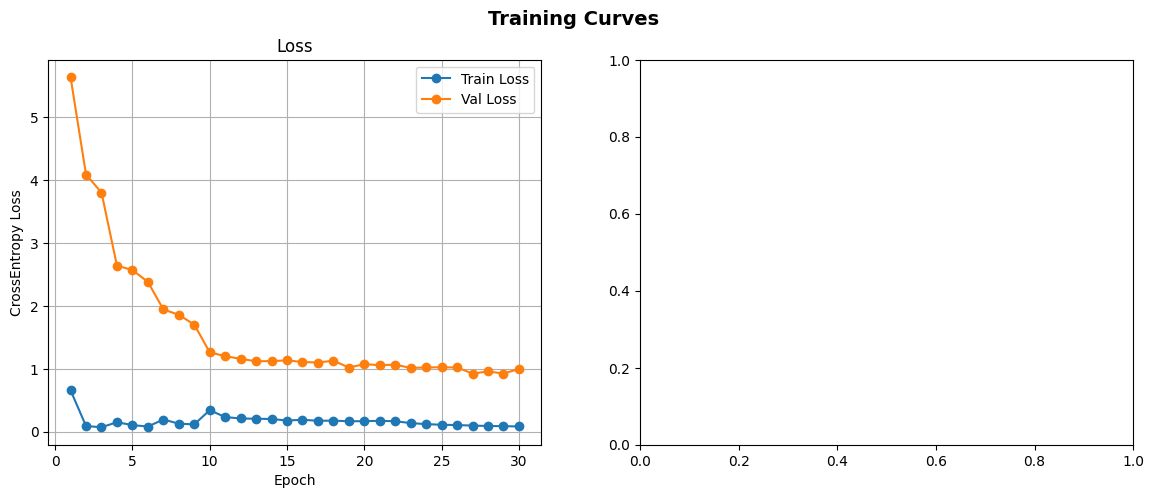

In [ ]:
# ============================================================
# STEP 6: TRAINING LOOP
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import json
import time
import os
from pathlib import Path

# ─────────────────────────────────────────
# 6.1 CONFIGURATION
# ─────────────────────────────────────────
LEARNING_RATE  = 0.001
NUM_EPOCHS     = 30
CLIP_GRAD      = 1.0
PATIENCE       = 5
CHECKPOINT_DIR = "./content/checkpoints"
LOG_INTERVAL   = 500    # print every N batches

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ─────────────────────────────────────────
# 6.2 LOSS FUNCTION
# ─────────────────────────────────────────
class_weights = torch.tensor(
    np.load(f"{DATA_DIR}/class_weights.npy"),
    dtype=torch.float32
).to(DEVICE)

criterion = nn.CrossEntropyLoss(
    weight       = class_weights,
    ignore_index = PAD_IDX
)

# ─────────────────────────────────────────
# 6.3 OPTIMIZER & SCHEDULER
# ─────────────────────────────────────────
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode    = 'min',     # minimize val_loss
    factor  = 0.5,       # halve the LR
    patience= 2         # wait 2 epochs before reducing
    #verbose = True
)

# ─────────────────────────────────────────
# 6.4 TEACHER FORCING SCHEDULE
# ─────────────────────────────────────────
def get_teacher_forcing_ratio(epoch: int) -> float:
    if epoch <= 3:
        return 1.0
    elif epoch <= 6:
        return 0.75
    elif epoch <= 9:
        return 0.5
    else:
        return 0.25

# ─────────────────────────────────────────
# 6.5 TOKEN ACCURACY
# ─────────────────────────────────────────
def compute_token_accuracy(output, target, pad_idx=PAD_IDX):
    """
    Compute accuracy over non-PAD positions only.

    Args:
        output : (batch, seq_len, vocab_size)
        target : (batch, seq_len)
    """
    predictions = output.argmax(dim=-1)       # (batch, seq_len)
    non_pad     = target != pad_idx           # (batch, seq_len) bool mask
    correct     = (predictions == target) & non_pad
    accuracy    = correct.sum().float() / non_pad.sum().float()
    return accuracy.item()

# ─────────────────────────────────────────
# 6.6 TRAIN ONE EPOCH
# ─────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion,
                clip, teacher_forcing, device):
    model.train()

    epoch_loss     = 0.0
    epoch_accuracy = 0.0
    n_batches      = len(loader)

    epoch_start    = time.time()   # ← total epoch timer
    interval_start = time.time()   # ← per-interval timer

    for batch_idx, (src, tgt, mask) in enumerate(loader):
        src  = src.to(device)
        tgt  = tgt.to(device)
        mask = mask.to(device)

        # print dynamic length for first 5 batches only
        # if batch_idx < 5:
        #     print(f"    [Batch {batch_idx+1}] "
        #           f"src shape: {src.shape} | "
        #           f"tgt shape: {tgt.shape}")


        optimizer.zero_grad()

        # Forward pass — pass full target, model handles shift
        output = model(src, tgt, mask,
                       teacher_forcing=teacher_forcing)
        # output : (batch, tgt_len-1, vocab_size)
        # target : tgt[:, 1:] → drop SOS

        target = tgt[:, 1:]   # (batch, tgt_len-1)

        # Compute accuracy before reshaping
        acc = compute_token_accuracy(output, target)

        # Reshape for CrossEntropyLoss
        # (batch * tgt_len-1, vocab_size)
        output_flat = output.reshape(-1, output.size(-1))
        target_flat = target.reshape(-1)

        loss = criterion(output_flat, target_flat)

        # Backward pass
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), clip
        )

        optimizer.step()

        epoch_loss     += loss.item()
        epoch_accuracy += acc

        # Periodic logging
        if (batch_idx + 1) % LOG_INTERVAL == 0:
            interval_elapsed = time.time() - interval_start  # ← time for last 500 batches
            total_elapsed    = time.time() - epoch_start     # ← time since epoch start
            print(f"    Batch {batch_idx+1:>6}/{n_batches} | "
                  f"Loss: {epoch_loss/(batch_idx+1):.4f} | "
                  f"Acc: {epoch_accuracy/(batch_idx+1):.4f} | "
                  f"Last {LOG_INTERVAL} batches: {interval_elapsed:.1f}s | "
                  f"Total: {total_elapsed:.1f}s")
            interval_start = time.time()   # ← reset interval timer after printing

    avg_loss = epoch_loss     / n_batches
    avg_acc  = epoch_accuracy / n_batches
    return avg_loss, avg_acc

# ─────────────────────────────────────────
# 6.7 EVALUATE ONE EPOCH
# ─────────────────────────────────────────
def evaluate_epoch(model, loader, criterion, device):
    model.eval()

    epoch_loss     = 0.0
    epoch_accuracy = 0.0
    n_batches      = len(loader)

    with torch.no_grad():
        for src, tgt, mask in loader:
            src  = src.to(device)
            tgt  = tgt.to(device)
            mask = mask.to(device)

            # No teacher forcing during evaluation
            output = model(src, tgt, mask, teacher_forcing=0.0)
            target = tgt[:, 1:]

            acc = compute_token_accuracy(output, target)

            output_flat = output.reshape(-1, output.size(-1))
            target_flat = target.reshape(-1)

            loss = criterion(output_flat, target_flat)

            epoch_loss     += loss.item()
            epoch_accuracy += acc

    avg_loss = epoch_loss     / n_batches
    avg_acc  = epoch_accuracy / n_batches
    return avg_loss, avg_acc

# ─────────────────────────────────────────
# 6.8 MAIN TRAINING LOOP
# ─────────────────────────────────────────
print("=" * 60)
print("Starting Training")
print("=" * 60)

best_val_loss    = float('inf')
epochs_no_improve= 0
history          = []

for epoch in range(1, NUM_EPOCHS + 1):
    tf_ratio = get_teacher_forcing_ratio(epoch)

    print(f"\nEpoch {epoch}/{NUM_EPOCHS} | "
          f"Teacher Forcing: {tf_ratio} | "
          f"LR: {optimizer.param_groups[0]['lr']:.6f}")
    print("-" * 60)

    epoch_start = time.time()

    # Train
    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, criterion,
        CLIP_GRAD, tf_ratio, DEVICE
    )

    # Validate
    val_loss, val_acc = evaluate_epoch(
        model, val_loader, criterion, DEVICE
    )

    epoch_time = time.time() - epoch_start

    # LR scheduler step
    scheduler.step(val_loss)

    # Log epoch results
    print(f"\n  Epoch {epoch:>2} Summary:")
    print(f"    Train Loss : {train_loss:.4f} | "
          f"Train Acc : {train_acc:.4f}")
    print(f"    Val   Loss : {val_loss:.4f}   | "
          f"Val   Acc : {val_acc:.4f}")
    print(f"    Time       : {epoch_time:.1f}s")

    history.append({
        "epoch"     : epoch,
        "train_loss": train_loss,
        "train_acc" : train_acc,
        "val_loss"  : val_loss,
        "val_acc"   : val_acc,
        "lr"        : optimizer.param_groups[0]['lr'],
        "tf_ratio"  : tf_ratio
    })

    # Checkpointing
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save({
            "epoch"      : epoch,
            "model_state": model.state_dict(),
            "optim_state": optimizer.state_dict(),
            "val_loss"   : val_loss,
            "val_acc"    : val_acc,
            "history"    : history
        }, f"{CHECKPOINT_DIR}/best_model.pt")
        print(f"    ✓ Best model saved (val_loss={val_loss:.4f})")
    else:
        epochs_no_improve += 1
        print(f"    No improvement for "
              f"{epochs_no_improve}/{PATIENCE} epochs")

    # Early stopping
    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch}")
        break

# ─────────────────────────────────────────
# 6.9 SAVE TRAINING HISTORY
# ─────────────────────────────────────────
with open(f"{CHECKPOINT_DIR}/history.json", 'w') as f:
    json.dump(history, f, indent=2)
print(f"\nTraining history saved → {CHECKPOINT_DIR}/history.json")

# ─────────────────────────────────────────
# 6.10 PLOT TRAINING CURVES
# ─────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training Curves", fontsize=14, fontweight='bold')

epochs_ran = [h["epoch"] for h in history]

# Loss curves
axes[0].plot(epochs_ran,
             [h["train_loss"] for h in history],
             label="Train Loss", marker='o')
axes[0].plot(epochs_ran,
             [h["val_loss"]   for h in history],
             label="Val Loss",   marker='o')
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CrossEntropy Loss")
axes[0].legend()
axes[0].grid(True)

# Accuracy curves
axes[1].plot(epochs_ran,
             [h["train_acc"] for h in history],
             label="Train Acc", marker='o')
axes[1].plot(epochs_ran,
             [h["val_acc"]   for h in history],
             label="Val Acc",   marker='o')
axes[1].set_title("Token Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f"{CHECKPOINT_DIR}/training_curves.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved.")

# ─────────────────────────────────────────
# 6.11 LOAD BEST MODEL
# ─────────────────────────────────────────
print("\nLoading best model for evaluation...")
checkpoint = torch.load(f"{CHECKPOINT_DIR}/best_model.pt")
model.load_state_dict(checkpoint["model_state"])
print(f"  Best model from epoch {checkpoint['epoch']} | "
      f"Val Loss: {checkpoint['val_loss']:.4f} | "
      f"Val Acc : {checkpoint['val_acc']:.4f}")

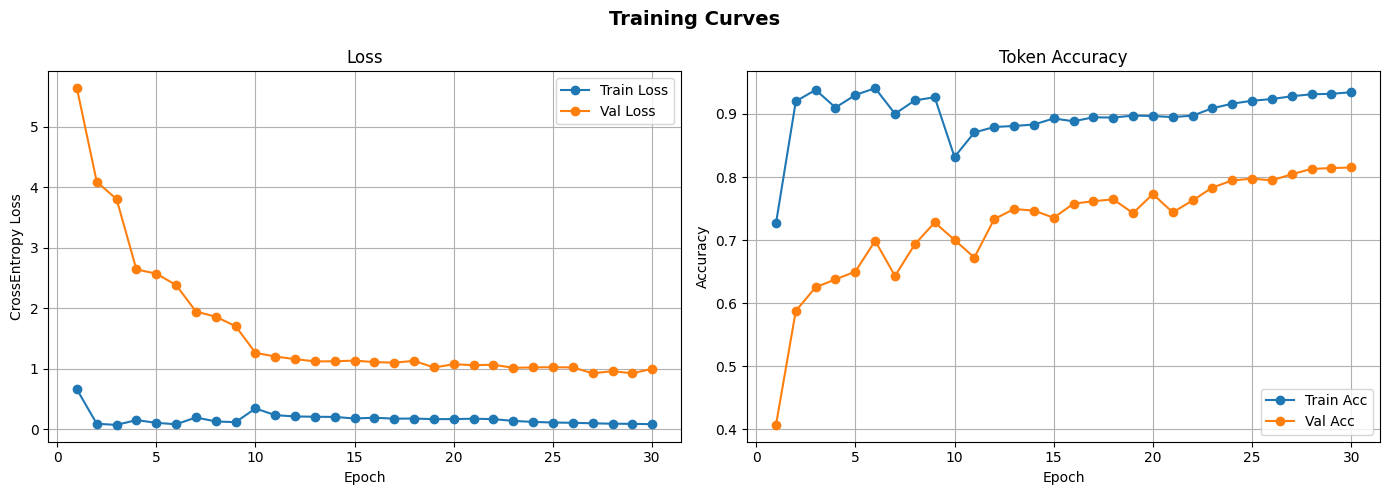

Training curves saved.

Loading best model for evaluation...
  Best model from epoch 27 | Val Loss: 0.9240 | Val Acc : 0.8044


In [ ]:
# ─────────────────────────────────────────
# 6.10 PLOT TRAINING CURVES
# ─────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training Curves", fontsize=14, fontweight='bold')

epochs_ran = [h["epoch"] for h in history]

# Loss curves
axes[0].plot(epochs_ran,
             [h["train_loss"] for h in history],
             label="Train Loss", marker='o')
axes[0].plot(epochs_ran,
             [h["val_loss"]   for h in history],
             label="Val Loss",   marker='o')
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CrossEntropy Loss")
axes[0].legend()
axes[0].grid(True)

# Accuracy curves
axes[1].plot(epochs_ran,
             [h["train_acc"] for h in history],
             label="Train Acc", marker='o')
axes[1].plot(epochs_ran,
             [h["val_acc"]   for h in history],
             label="Val Acc",   marker='o')
axes[1].set_title("Token Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f"{CHECKPOINT_DIR}/training_curves.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved.")

# ─────────────────────────────────────────
# 6.11 LOAD BEST MODEL
# ─────────────────────────────────────────
print("\nLoading best model for evaluation...")
checkpoint = torch.load(f"{CHECKPOINT_DIR}/best_model.pt")
model.load_state_dict(checkpoint["model_state"])
print(f"  Best model from epoch {checkpoint['epoch']} | "
      f"Val Loss: {checkpoint['val_loss']:.4f} | "
      f"Val Acc : {checkpoint['val_acc']:.4f}")

Starting Evaluation on Test Set

[1/5] Generating predictions...
  Generated 5,000 predictions

[2/5] Computing DER...
  Full DER        : 0.2602  (26.02%)
  Case-Ending DER : 0.2099  (20.99%)

[3/5] Computing WER...
  WER             : 0.3564  (35.64%)

[4/5] Computing BLEU...
  BLEU            : 0.7860  (78.60%)

[5/5] Per-Diacritic Analysis...

  Diacritic              Accuracy    Correct      Total
  ----------------------------------------------------
  Sukun                    76.34%     22,230     29,118
  Damma                    75.42%     16,222     21,508
  Fatha                    73.79%     57,710     78,213
  Kasra                    72.93%     22,547     30,916
  Tanwin Damm              67.12%        941      1,402
  Shadda                   66.65%      7,377     11,069
  Tanwin Kasr              66.09%      1,292      1,955
  Tanwin Fath              61.53%        766      1,245

[+] Qualitative Examples...

--- Best Predictions (lowest DER) ---

  REF : حَاشِيَةُ السّ

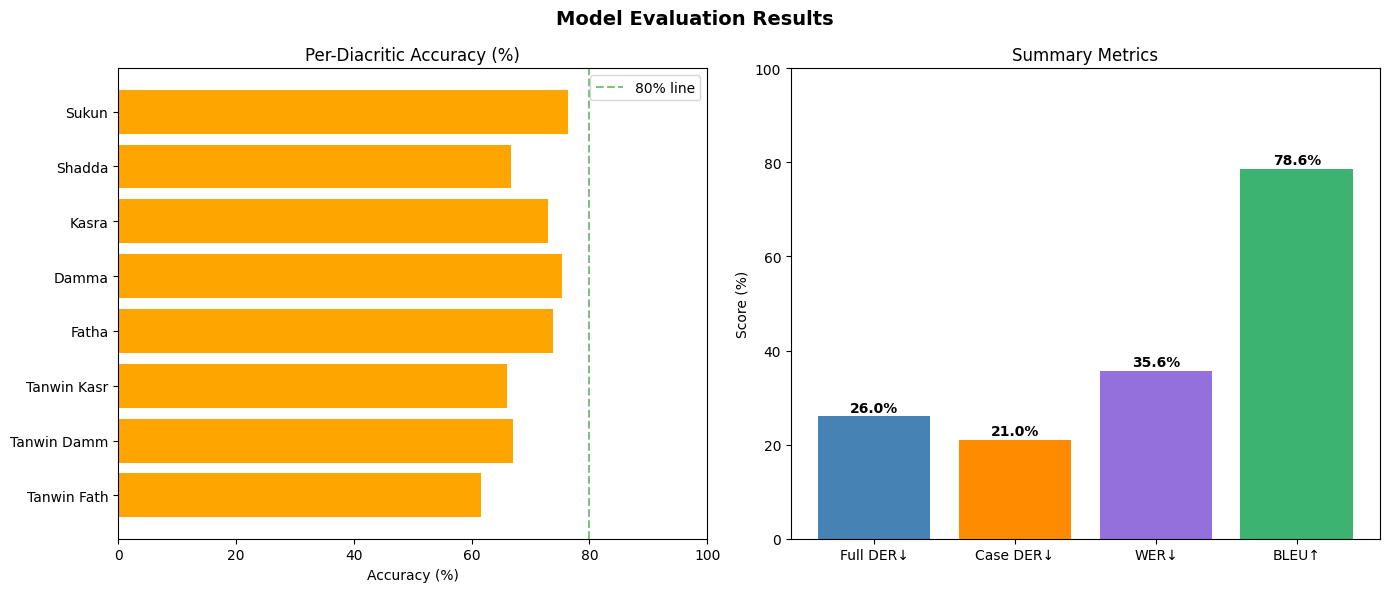

Evaluation plot saved.

FINAL EVALUATION SUMMARY
  Full DER        : 26.02%
  Case-Ending DER : 20.99%
  WER             : 35.64%
  BLEU            : 78.60%
  Test samples    : 5,000

Evaluation complete.


In [ ]:
# ============================================================
# STEP 7: EVALUATION & ERROR ANALYSIS
# ============================================================

import torch
import json
import numpy as np
from collections import defaultdict
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ─────────────────────────────────────────
# 7.1 CONFIGURATION
# ─────────────────────────────────────────
DIACRITICS = {
    '\u064B': 'Tanwin Fath',
    '\u064C': 'Tanwin Damm',
    '\u064D': 'Tanwin Kasr',
    '\u064E': 'Fatha',
    '\u064F': 'Damma',
    '\u0650': 'Kasra',
    '\u0651': 'Shadda',
    '\u0652': 'Sukun',
}
DIAC_SET = set(DIACRITICS.keys())

# ─────────────────────────────────────────
# 7.2 GENERATE PREDICTIONS ON TEST SET
# ─────────────────────────────────────────
def generate_predictions(model, loader, target_vocab, device,
                          max_batches=None):
    """
    Run inference on the test set.
    Returns lists of (reference_string, prediction_string).
    """
    model.eval()
    references  = []
    predictions = []

    with torch.no_grad():
        for batch_idx, (src, tgt, mask) in enumerate(loader):
            if max_batches and batch_idx >= max_batches:
                break

            src  = src.to(device)
            mask = mask.to(device)

            # Greedy decoding — no teacher forcing
            pred_indices = model.predict(src, mask)

            # Decode each sample in batch
            for i in range(src.size(0)):
                # Reference: decode target (skip PAD/SOS/EOS)
                ref_indices = tgt[i].tolist()
                ref_str     = target_vocab.decode(
                    ref_indices, remove_special=True
                )

                # Prediction: decode model output
                pred_str = target_vocab.decode(
                    pred_indices[i].tolist(), remove_special=True
                )

                references.append(ref_str)
                predictions.append(pred_str)

    print(f"  Generated {len(predictions):,} predictions")
    return references, predictions

# ─────────────────────────────────────────
# 7.3 DER COMPUTATION
# ─────────────────────────────────────────
def compute_der(references, predictions):
    """
    Diacritic Error Rate — compares diacritics at each
    base character position.

    Returns:
        full_der         : overall DER
        case_ending_der  : DER on last letter of each word only
    """
    total_diacs        = 0
    wrong_diacs        = 0
    total_case_endings = 0
    wrong_case_endings = 0

    for ref, pred in zip(references, predictions):
        # Extract (base_char, diacritic_or_None) pairs
        ref_pairs  = extract_char_diac_pairs(ref)
        pred_pairs = extract_char_diac_pairs(pred)

        # Align by base characters (zip to shorter)
        for pos, ((r_char, r_diac), (p_char, p_diac)) in \
                enumerate(zip(ref_pairs, pred_pairs)):

            if r_diac is not None:
                total_diacs += 1
                if r_diac != p_diac:
                    wrong_diacs += 1

        # Case endings: last base char of each word
        ref_words  = ref.split()
        pred_words = pred.split()

        for r_word, p_word in zip(ref_words, pred_words):
            r_pairs = extract_char_diac_pairs(r_word)
            p_pairs = extract_char_diac_pairs(p_word)

            if not r_pairs:
                continue

            # Last character pair
            r_last_char, r_last_diac = r_pairs[-1]
            p_last_char, p_last_diac = p_pairs[-1] \
                if p_pairs else (None, None)

            if r_last_diac is not None:
                total_case_endings += 1
                if r_last_diac != p_last_diac:
                    wrong_case_endings += 1

    full_der        = wrong_diacs / total_diacs \
                      if total_diacs > 0 else 0
    case_ending_der = wrong_case_endings / total_case_endings \
                      if total_case_endings > 0 else 0

    return full_der, case_ending_der

def extract_char_diac_pairs(text):
    """
    Convert Arabic text to list of (base_char, diacritic) pairs.
    base_char  : Arabic letter
    diacritic  : diacritic char or None if undiacritized
    """
    pairs = []
    i = 0
    while i < len(text):
        char = text[i]
        if char in DIAC_SET or char == ' ':
            i += 1
            continue

        # Base character — look ahead for diacritic(s)
        diac = None
        j = i + 1
        while j < len(text) and text[j] in DIAC_SET:
            # Handle Shadda + vowel combinations
            if diac is None:
                diac = text[j]
            else:
                diac += text[j]  # compound diacritic
            j += 1

        pairs.append((char, diac))
        i = j

    return pairs

# ─────────────────────────────────────────
# 7.4 WER COMPUTATION
# ─────────────────────────────────────────
def compute_wer(references, predictions):
    """
    Word Error Rate — a word is wrong if it differs
    from reference in any character.
    """
    total_words = 0
    wrong_words = 0

    for ref, pred in zip(references, predictions):
        ref_words  = ref.split()
        pred_words = pred.split()

        for r_word, p_word in zip(ref_words, pred_words):
            total_words += 1
            if r_word != p_word:
                wrong_words += 1

        # Count unmatched words (length difference)
        length_diff  = abs(len(ref_words) - len(pred_words))
        total_words += length_diff
        wrong_words += length_diff

    return wrong_words / total_words if total_words > 0 else 0

# ─────────────────────────────────────────
# 7.5 BLEU COMPUTATION
# ─────────────────────────────────────────
def compute_bleu(references, predictions):
    """
    Character-level BLEU score.
    """
    # Format for nltk: list of [reference_tokens] per sample
    refs_tokenized  = [[list(ref)]  for ref  in references]
    preds_tokenized = [list(pred)   for pred in predictions]

    smoother = SmoothingFunction().method1
    bleu     = corpus_bleu(
        refs_tokenized,
        preds_tokenized,
        smoothing_function=smoother
    )
    return bleu

# ─────────────────────────────────────────
# 7.6 PER-DIACRITIC ACCURACY
# ─────────────────────────────────────────
def compute_per_diacritic_accuracy(references, predictions):
    """
    For each diacritic, compute how often the model
    predicts it correctly when it appears in reference.
    """
    diac_correct = defaultdict(int)
    diac_total   = defaultdict(int)

    for ref, pred in zip(references, predictions):
        ref_pairs  = extract_char_diac_pairs(ref)
        pred_pairs = extract_char_diac_pairs(pred)

        for (r_char, r_diac), (p_char, p_diac) in \
                zip(ref_pairs, pred_pairs):
            if r_diac is None:
                continue
            # Handle compound diacritics (Shadda+vowel)
            for d in r_diac:
                if d in DIAC_SET:
                    diac_total[d]   += 1
                    if r_diac == p_diac:
                        diac_correct[d] += 1

    results = {}
    for diac, name in DIACRITICS.items():
        total   = diac_total[diac]
        correct = diac_correct[diac]
        acc     = correct / total if total > 0 else 0
        results[name] = {
            "accuracy": acc,
            "total"   : total,
            "correct" : correct
        }
    return results

# ─────────────────────────────────────────
# 7.7 QUALITATIVE EXAMPLES
# ─────────────────────────────────────────
def show_qualitative_examples(references, predictions, n=5):
    """
    Show side-by-side reference vs prediction examples.
    Selects a mix of good and bad predictions.
    """
    # Compute per-sample DER for selection
    sample_ders = []
    for ref, pred in zip(references, predictions):
        der, _ = compute_der([ref], [pred])
        sample_ders.append(der)

    sample_ders = np.array(sample_ders)

    print("\n--- Best Predictions (lowest DER) ---")
    best_idx = np.argsort(sample_ders)[:n]
    for idx in best_idx:
        print(f"\n  REF : {references[idx][:80]}")
        print(f"  PRED: {predictions[idx][:80]}")
        print(f"  DER : {sample_ders[idx]:.4f}")

    print("\n--- Worst Predictions (highest DER) ---")
    worst_idx = np.argsort(sample_ders)[-n:][::-1]
    for idx in worst_idx:
        print(f"\n  REF : {references[idx][:80]}")
        print(f"  PRED: {predictions[idx][:80]}")
        print(f"  DER : {sample_ders[idx]:.4f}")

# ─────────────────────────────────────────
# 7.8 VISUALIZATION
# ─────────────────────────────────────────
def plot_evaluation(per_diac_acc, full_der,
                    case_der, wer, bleu):

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("Model Evaluation Results",
                 fontsize=14, fontweight='bold')

    # Plot 1: Per-diacritic accuracy
    names = list(per_diac_acc.keys())
    accs  = [per_diac_acc[n]["accuracy"] * 100 for n in names]
    colors = ['green' if a >= 80 else
              'orange' if a >= 60 else
              'red' for a in accs]

    axes[0].barh(names, accs, color=colors)
    axes[0].axvline(80, color='green',
                    linestyle='--', alpha=0.5, label='80% line')
    axes[0].set_title("Per-Diacritic Accuracy (%)")
    axes[0].set_xlabel("Accuracy (%)")
    axes[0].set_xlim(0, 100)
    axes[0].legend()

    # Plot 2: Summary metrics
    metrics = ['Full DER↓', 'Case DER↓', 'WER↓', 'BLEU↑']
    values  = [full_der * 100, case_der * 100,
               wer * 100, bleu * 100]
    bar_colors = ['steelblue', 'darkorange',
                  'mediumpurple', 'mediumseagreen']

    bars = axes[1].bar(metrics, values, color=bar_colors)
    axes[1].set_title("Summary Metrics")
    axes[1].set_ylabel("Score (%)")
    axes[1].set_ylim(0, 100)

    for bar, val in zip(bars, values):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f'{val:.1f}%',
            ha='center', fontweight='bold'
        )

    plt.tight_layout()
    # plt.savefig(f"{CHECKPOINT_DIR}/evaluation.png",
    #             dpi=150, bbox_inches='tight')
    plt.show()
    print("Evaluation plot saved.")

# ─────────────────────────────────────────
# 7.9 MAIN EVALUATION
# ─────────────────────────────────────────
print("=" * 60)
print("Starting Evaluation on Test Set")
print("=" * 60)

MODEL_PATH   = "best_model.pt"
HISTORY_PATH = "history.json"

# Generate predictions
print("\n[1/5] Generating predictions...")
references, predictions = generate_predictions(
    model, test_loader, target_vocab, DEVICE
)

# DER
print("\n[2/5] Computing DER...")
full_der, case_ending_der = compute_der(references, predictions)
print(f"  Full DER        : {full_der:.4f}  ({full_der*100:.2f}%)")
print(f"  Case-Ending DER : {case_ending_der:.4f}  "
      f"({case_ending_der*100:.2f}%)")

# WER
print("\n[3/5] Computing WER...")
wer = compute_wer(references, predictions)
print(f"  WER             : {wer:.4f}  ({wer*100:.2f}%)")

# BLEU
print("\n[4/5] Computing BLEU...")
bleu = compute_bleu(references, predictions)
print(f"  BLEU            : {bleu:.4f}  ({bleu*100:.2f}%)")

# Per-diacritic accuracy
print("\n[5/5] Per-Diacritic Analysis...")
per_diac_acc = compute_per_diacritic_accuracy(
    references, predictions
)
print(f"\n  {'Diacritic':<20} {'Accuracy':>10} "
      f"{'Correct':>10} {'Total':>10}")
print("  " + "-" * 52)
for name, stats in sorted(per_diac_acc.items(),
                           key=lambda x: x[1]['accuracy'],
                           reverse=True):
    print(f"  {name:<20} "
          f"{stats['accuracy']*100:>9.2f}% "
          f"{stats['correct']:>10,} "
          f"{stats['total']:>10,}")

# Qualitative examples
print("\n[+] Qualitative Examples...")
show_qualitative_examples(references, predictions, n=3)

# Visualize
print("\n[+] Plotting results...")
plot_evaluation(per_diac_acc, full_der,
                case_ending_der, wer, bleu)

# ─────────────────────────────────────────
# 7.10 FINAL SUMMARY
# ─────────────────────────────────────────
print("\n" + "="*60)
print("FINAL EVALUATION SUMMARY")
print("="*60)
print(f"  Full DER        : {full_der*100:.2f}%")
print(f"  Case-Ending DER : {case_ending_der*100:.2f}%")
print(f"  WER             : {wer*100:.2f}%")
print(f"  BLEU            : {bleu*100:.2f}%")
print(f"  Test samples    : {len(references):,}")
print("\nEvaluation complete.")

In [ ]:
import os
MODEL_PATH   = "./content/checkpoints/best_model.pt"
HISTORY_PATH = "./content/checkpoints/history.json"

print("\nInstantiating model...")
encoder = Encoder(INPUT_VOCAB_SIZE,  EMBED_DIM,
                  HIDDEN_DIM, NUM_LAYERS, DROPOUT)
decoder = Decoder(OUTPUT_VOCAB_SIZE, EMBED_DIM,
                  HIDDEN_DIM, NUM_LAYERS, DROPOUT)
model   = Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)

print("Loading checkpoint weights...")
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()

print(f"  Loaded from epoch : {checkpoint['epoch']}")
print(f"  Val Loss          : {checkpoint['val_loss']:.4f}")
print(f"  Val Acc           : {checkpoint['val_acc']:.4f}")


Instantiating model...
Loading checkpoint weights...
  Loaded from epoch : 27
  Val Loss          : 0.9240
  Val Acc           : 0.8044


In [ ]:
########## Added by Omar

MODEL_PATH   = "best_model (1).pt"
HISTORY_PATH = "history (1).json"

print("\nInstantiating model...")
encoder = Encoder(INPUT_VOCAB_SIZE,  EMBED_DIM,
                  HIDDEN_DIM, NUM_LAYERS, DROPOUT)
decoder = Decoder(OUTPUT_VOCAB_SIZE, EMBED_DIM,
                  HIDDEN_DIM, NUM_LAYERS, DROPOUT)
model   = Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)

print("Loading checkpoint weights...")
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()

print(f"  Loaded from epoch : {checkpoint['epoch']}")
print(f"  Val Loss          : {checkpoint['val_loss']:.4f}")
print(f"  Val Acc           : {checkpoint['val_acc']:.4f}")


Instantiating model...
Loading checkpoint weights...
  Loaded from epoch : 27
  Val Loss          : 0.9240
  Val Acc           : 0.8044


In [ ]:
per_diac_acc

{'Tanwin Fath': {'accuracy': 0.6152610441767068,
  'total': 1245,
  'correct': 766},
 'Tanwin Damm': {'accuracy': 0.6711840228245364,
  'total': 1402,
  'correct': 941},
 'Tanwin Kasr': {'accuracy': 0.6608695652173913,
  'total': 1955,
  'correct': 1292},
 'Fatha': {'accuracy': 0.7378568780126066, 'total': 78213, 'correct': 57710},
 'Damma': {'accuracy': 0.754230983819974, 'total': 21508, 'correct': 16222},
 'Kasra': {'accuracy': 0.7292987449864148, 'total': 30916, 'correct': 22547},
 'Shadda': {'accuracy': 0.6664558677387298, 'total': 11069, 'correct': 7377},
 'Sukun': {'accuracy': 0.7634452915722234, 'total': 29118, 'correct': 22230}}

In [ ]:
# ============================================================
# RESULTS: SAVE & COMPARE
# ============================================================

import json
import matplotlib.pyplot as plt
import numpy as np

RESULTS_PATH = "results.json"

# ─────────────────────────────────────────
# 1. LOAD EXISTING RESULTS & APPEND OURS
# ─────────────────────────────────────────
with open(RESULTS_PATH, 'r', encoding='utf-8') as f:
    results = json.load(f)

print("Existing models in results.json:")
for model_name in results:
    print(f"  - {model_name}")

# Add our model's results
results["Seq2Seq + Bahdanau Attention"] = {
    "Per-Diacritic results": per_diac_acc,
    "bleu"            : round(bleu, 4),
    "full_der"        : round(full_der, 4),
    "case_ending_der" : round(case_ending_der, 4),
    "wer"             : round(wer, 4),
}

# Save back
with open(RESULTS_PATH, 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print("\nUpdated results.json saved ✓")

# ─────────────────────────────────────────
# 2. RELOAD & VERIFY
# ─────────────────────────────────────────
with open(RESULTS_PATH, 'r', encoding='utf-8') as f:
    results = json.load(f)

print("\nAll models in results.json:")
for model_name, metrics in results.items():
    print(f"\n  {model_name}")
    for metric, value in metrics.items():
        print(f"    {metric:>20} : {value}")


Existing models in results.json:
  - Seq2Seq + Bahdanau Attention

Updated results.json saved ✓

All models in results.json:

  Seq2Seq + Bahdanau Attention
    Per-Diacritic results : {'Tanwin Fath': {'accuracy': 0.6152610441767068, 'total': 1245, 'correct': 766}, 'Tanwin Damm': {'accuracy': 0.6711840228245364, 'total': 1402, 'correct': 941}, 'Tanwin Kasr': {'accuracy': 0.6608695652173913, 'total': 1955, 'correct': 1292}, 'Fatha': {'accuracy': 0.7378568780126066, 'total': 78213, 'correct': 57710}, 'Damma': {'accuracy': 0.754230983819974, 'total': 21508, 'correct': 16222}, 'Kasra': {'accuracy': 0.7292987449864148, 'total': 30916, 'correct': 22547}, 'Shadda': {'accuracy': 0.6664558677387298, 'total': 11069, 'correct': 7377}, 'Sukun': {'accuracy': 0.7634452915722234, 'total': 29118, 'correct': 22230}}
                    bleu : 0.786
                full_der : 0.2602
         case_ending_der : 0.2099
                     wer : 0.3564
